In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
compute_mmca_init_gamma.py

运行MMCA模拟，参数为四组 (init_frac, gamma) 组合：
(0.20, 0.02), (0.20, 0.03), (0.80, 0.02), (0.80, 0.03)
"""

import os
import time
import math
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# -------------------- 超图生成器 --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- MMCA 类 --------------------
class HyperSISMMCA:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def run_mmca(self, beta_d, mu, eta, gamma, T=1000, init_frac=0.01):
        """
        运行MMCA模拟T个时间步
        返回: rho, theta_mean, phi_median 的时间序列
        """
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        
        rho_hist = []
        theta_hist = []
        phi_hist = []
        
        for t in range(T):
            # 计算感染密度
            rho_hist.append(p.mean())
            
            # 计算边的乘积
            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
            
            # 计算Q_i
            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        oth = prod_pos0[ei]
                    elif pos == 1:
                        oth = prod_pos1[ei]
                    else:
                        oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * oth)
                Q[node] = prod_val
            
            # 更新p
            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            
            # 计算Phi并更新Theta
            p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
            Phi = p_i * p_j * p_k
            Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
            Theta_next = np.clip(Theta_next, 0.0, 1.0)
            
            # 记录统计量
            theta_hist.append(Theta.mean())
            phi_hist.append(np.median(Phi))
            
            p = p_next
            Theta = Theta_next
        
        return np.array(rho_hist), np.array(theta_hist), np.array(phi_hist)

# -------------------- 并行任务函数 --------------------
def run_single_simulation(params):
    """
    单个模拟任务的并行执行函数
    """
    (init_frac, gamma, rep, n, kappa, beta, mu, eta, T, seed_base) = params
    
    # 生成随机种子
    gen_seed = None if seed_base is None else (seed_base + rep)
    
    # 生成超图并运行模拟
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed)
    model = HyperSISMMCA(hyperedges, n)
    
    rho, theta, phi = model.run_mmca(
        beta_d=beta, mu=mu, eta=eta, gamma=gamma, 
        T=T, init_frac=init_frac
    )
    
    return {
        'init_frac': init_frac,
        'gamma': gamma,
        'rep': rep,
        'rho': rho,
        'theta': theta,
        'phi': phi
    }

# -------------------- 主程序 --------------------
def main():
    # --------------------- Parameters (edit here) ---------------------
    n = 1500
    kappa = 6.0
    beta = 0.20
    mu = 0.1
    eta = 0.6  # 固定eta值
    T = 1000
    seed_base = 12345

    # 四组 (init_frac, gamma) 组合
    param_pairs = [
        (0.20, 0.02),
        (0.20, 0.03), 
        (0.80, 0.02),
        (0.80, 0.03)
    ]

    out_dir = "mmca_init_gamma_repeat_out"
    os.makedirs(out_dir, exist_ok=True)

    # 并行参数
    num_repeats = 30
    n_jobs = 18  # 根据你的CPU调整

    # --------------------- 并行运行模拟 ---------------------
    print("开始运行MMCA模拟...")
    t0 = time.time()

    # 准备所有参数组合
    param_combinations = []
    for (init_frac, gamma) in param_pairs:
        for rep in range(num_repeats):
            params = (init_frac, gamma, rep, n, kappa, beta, mu, eta, T, seed_base)
            param_combinations.append(params)

    print(f"总任务数: {len(param_combinations)} (4组参数 × {num_repeats}次重复)")

    # 并行执行
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(run_single_simulation)(params) for params in param_combinations
    )

    # --------------------- 处理并保存结果 ---------------------
    print("处理结果...")
    
    # 按参数分组结果
    grouped_results = {}
    for (init_frac, gamma) in param_pairs:
        key = (init_frac, gamma)
        grouped_results[key] = [r for r in results if r['init_frac'] == init_frac and r['gamma'] == gamma]

    # 计算平均值并保存
    for (init_frac, gamma), rep_results in grouped_results.items():
        # 提取所有重复的rho, theta, phi
        rho_all = np.array([r['rho'] for r in rep_results])
        theta_all = np.array([r['theta'] for r in rep_results]) 
        phi_all = np.array([r['phi'] for r in rep_results])
        
        # 计算平均值
        rho_avg = rho_all.mean(axis=0)
        theta_avg = theta_all.mean(axis=0)
        phi_avg = phi_all.mean(axis=0)
        
        # 保存平均结果
        fn = os.path.join(out_dir, f"init{init_frac:.2f}_gamma{gamma:.2f}_avg.csv")
        t_arr = np.arange(T)
        df = pd.DataFrame({
            'time': t_arr, 
            'rho': rho_avg, 
            'theta_mean': theta_avg, 
            'phi_median': phi_avg
        })
        df.to_csv(fn, index=False, float_format="%.6f")
        print(f"保存 -> {fn}")

    elapsed = time.time() - t0
    print(f"全部完成! 耗时: {elapsed:.1f}s")
    print(f"结果保存在: {out_dir}")

if __name__ == "__main__":
    main()

开始运行MMCA模拟...
总任务数: 120 (4组参数 × 30次重复)


[Parallel(n_jobs=18)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    6.3s


处理结果...
保存 -> mmca_init_gamma_repeat_out\init0.20_gamma0.02_avg.csv
保存 -> mmca_init_gamma_repeat_out\init0.20_gamma0.03_avg.csv
保存 -> mmca_init_gamma_repeat_out\init0.80_gamma0.02_avg.csv
保存 -> mmca_init_gamma_repeat_out\init0.80_gamma0.03_avg.csv
全部完成! 耗时: 37.0s
结果保存在: mmca_init_gamma_repeat_out


[Parallel(n_jobs=18)]: Done 120 out of 120 | elapsed:   36.8s finished


图片已保存: mmca_init_gamma_curves.pdf


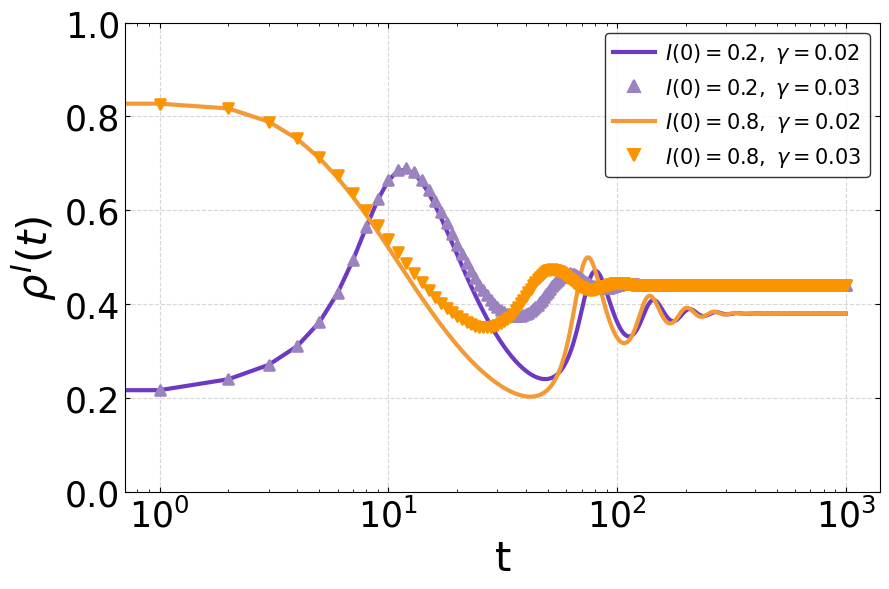

In [ ]:
#!/usr/bin/env python3
# plot_mmca_init_gamma_curves.py

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ===================== User Config =====================
DATA_DIR = "mmca_init_gamma_repeat_out"

# 所有数据对 - 现在使用 (init_frac, gamma)
pairs = [
    (0.20, 0.02),  # 直线1
    (0.20, 0.03),  # 散点1  
    (0.80, 0.02),  # 直线2
    (0.80, 0.03)   # 散点2
]

# 颜色配置
colors = ["#6D39C2", "#9A83BE", '#F39936', '#fa9500']

# 标签配置 - 改为显示 gamma
labels = [fr'$I(0)={i}, \  \gamma={g}$' for (i,g) in pairs]

# 样式配置：交替使用直线和散点
plot_types = ['line', 'scatter', 'line', 'scatter']  # 定义每条线的类型
linestyles = ['-', '', '-', '']  # 散点图不需要线型
markers = ['', '^', '', 'v']     # 直线不需要标记，散点需要
# ========================================================

# ---------- Load data ----------
dfs = []
for (init, gamma) in pairs:
    # 文件名改为包含gamma
    fn = os.path.join(DATA_DIR, f"init{init:.2f}_gamma{gamma:.2f}_avg.csv")
    if not os.path.exists(fn):
        print(f"警告: 找不到文件 {fn}")
        continue
    df = pd.read_csv(fn)
    dfs.append(df)

if len(dfs) == 0:
    print("错误: 没有找到任何数据文件!")
    exit(1)

# ---------- Plot rho(t) ----------
plt.figure(figsize=(9,6))

# 存储图例句柄和标签
legend_handles = []
legend_labels = []

# 按顺序绘制所有曲线
for i, (df, lab, col, plot_type, ls, marker) in enumerate(zip(dfs, labels, colors, plot_types, linestyles, markers)):
    time = df["time"].values
    rho = df["rho"].values
    
    if plot_type == 'line':
        # 绘制线条
        line = plt.plot(time, rho, 
                       linestyle=ls, 
                       label=lab, 
                       linewidth=3, 
                       color=col)[0]
        legend_handles.append(line)
        
    else:  # scatter
        # 绘制散点（每隔10个点取一个，避免过于密集）
        # indices = np.arange(0, len(time), 10)
        scatter = plt.scatter(time, rho,
                             marker=marker,
                             s=50,
                             facecolor=col,
                             edgecolor=col,
                             linewidth=2,
                             label=lab,
                             zorder=3)
        # 创建散点的图例句柄
        scatter_handle = Line2D([0], [0], 
                               marker=marker, 
                               color='w', 
                               markerfacecolor=col,
                               markeredgecolor=col,
                               markersize=8,
                               markeredgewidth=1.5)
        legend_handles.append(scatter_handle)
    
    legend_labels.append(lab)

plt.xlabel("t", fontsize=30)
plt.ylabel("$\\rho^I(t)$", fontsize=30)
plt.xscale("log")
plt.yscale("linear")
plt.yticks(fontsize=25)
plt.ylim(0, 1)
plt.xticks(fontsize=25)

# 使用自定义的图例句柄和标签创建图例
legend = plt.legend(legend_handles, legend_labels,
                   loc='upper right',
                   fontsize=15,
                   handletextpad=0.5,
                   borderpad=0.4,
                   handlelength=2.0,
                   )

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

plt.tick_params(
    axis='both',
    which='both',
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
    direction='in',
)

plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()

# 保存图片 - 文件名改为反映gamma
plt.savefig('mmca_init_gamma_curves.pdf', bbox_inches='tight', dpi=300)
print("图片已保存: mmca_init_gamma_curves.pdf")
plt.show()